# 📊 DỰ ÁN 1 — XÂY DỰNG MÔ HÌNH PHÂN LOẠI VÀ DỰ BÁO RỦI RO KHÁCH HÀNG VAY VỐN

**Notebook 06/07 — Machine Learning (Huấn luyện & đánh giá mô hình)**

---

**🎯 Mục tiêu:** Huấn luyện và so sánh các mô hình phân loại rủi ro tín dụng (Logistic Regression, Random Forest, HistGradientBoosting); đánh giá bằng độ đo phù hợp với dữ liệu mất cân bằng (**AUC-ROC**, không dùng accuracy); chọn và lưu mô hình tốt nhất.

**📥 Input:** `data/processed/train_features.csv` — bảng đặc trưng hoàn chỉnh (từ Notebook 05).

**📤 Output:** `models/model.pkl` — mô hình tốt nhất; `models/model_metadata.json` — danh sách đặc trưng theo đúng thứ tự, ngưỡng quyết định và điểm AUC (app Streamlit và Notebook 07 cần file này để dựng đúng đầu vào).

**🔗 Pipeline:** 05. Feature Engineering → **06. Machine Learning** → 07. Prediction Demo

## ⚙️ Điều kiện trước khi chạy (đọc trước)

Notebook này **KHÔNG** cần PostgreSQL, **KHÔNG** cần `.env`, **KHÔNG** cần chạy notebook 02 hay 04 (xem `README.md` mục 5 — pipeline chia làm 2 nhánh độc lập). Chỉ cần:

1. **⚠️ Chạy Notebook 03 → rồi Notebook 05 TRƯỚC.** Notebook này nạp `data/processed/train_features.csv`, là **output của Notebook 05**. Chưa chạy NB05 thì ô nạp dữ liệu ở mục 2 sẽ lỗi `FileNotFoundError`.
2. **Cài thư viện:** `pip install -r requirements.txt`. Notebook chỉ dùng `scikit-learn` — **không** cần LightGBM/XGBoost.
3. **RAM:** chạy toàn bộ dữ liệu (307.511 × 299) tốn khoảng **1,5–2 GB**. Máy yếu RAM đặt `DEBUG = True` ở mục 1 để chạy thử trên mẫu 50.000 dòng.

> **📌 Ghi chú về phạm vi (quan trọng khi đọc kết quả):** notebook này cố tình dựng **mốc nền (baseline)** trên bộ đặc trưng hiện có để có `model.pkl` sớm, vì các task khác (app Streamlit, notebook 07, Chương 4 báo cáo) đều đang chờ file này. Việc **tinh chỉnh siêu tham số** để đẩy AUC lên cao hơn thuộc về task T24, không làm ở đây.

## 1. Chuẩn bị môi trường & Thiết lập cấu hình

Nạp thư viện, cố định `RANDOM_STATE` để kết quả **tái lập được** giữa các máy, và khai báo đường dẫn input/output.

In [1]:
import gc
import json
import time
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score,
    confusion_matrix, classification_report, precision_recall_fscore_support,
)

# ⚠️ KHÔNG dùng warnings.filterwarnings("ignore") cho TẤT CẢ cảnh báo.
# Ở NB03 chính dòng đó đã nuốt mất ChainedAssignmentError của pandas 3 (Copy-on-Write),
# khiến một bước làm sạch thất bại ÂM THẦM mà không ai biết.
# Chỉ tắt các cảnh báo "ồn ào" KHÔNG liên quan tới tính đúng đắn của kết quả.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# --- Cấu hình ---------------------------------------------------------------
# DEBUG = True  -> chỉ đọc 50.000 dòng đầu, dùng khi máy yếu RAM hoặc muốn chạy thử nhanh.
# DEBUG = False -> chạy TOÀN BỘ 307.511 dòng (mặc định, tạo model chính thức).
DEBUG = False
DEBUG_ROWS = 50_000
RANDOM_STATE = 42
TEST_SIZE = 0.2

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
MODELS_DIR = PROJECT_DIR / "models"
TRAIN_FEATURES_PATH = DATA_PROCESSED / "train_features.csv"
MODEL_PATH = MODELS_DIR / "model.pkl"
METADATA_PATH = MODELS_DIR / "model_metadata.json"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Thư mục dự án : {PROJECT_DIR}")
print(f"File đặc trưng: {TRAIN_FEATURES_PATH}")
print(f"Tồn tại       : {TRAIN_FEATURES_PATH.exists()}")
print(f"Chế độ DEBUG  : {DEBUG}" + (f" (chỉ đọc {DEBUG_ROWS:,} dòng)" if DEBUG else " (chạy toàn bộ dữ liệu)"))

# Dừng ngay với thông báo rõ ràng thay vì để lỗi khó hiểu ở ô sau.
assert TRAIN_FEATURES_PATH.exists(), (
    f"Không tìm thấy {TRAIN_FEATURES_PATH}. Bạn cần chạy Notebook 03 rồi Notebook 05 trước."
)

Thư mục dự án : D:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier
File đặc trưng: D:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\data\processed\train_features.csv
Tồn tại       : True
Chế độ DEBUG  : False (chạy toàn bộ dữ liệu)


**Nhận xét:** Đường dẫn đã trỏ đúng tới bảng đặc trưng do Notebook 05 sinh ra. Chế độ `DEBUG` mặc định **tắt** (`False`) — notebook chạy trên toàn bộ 307.511 dòng để tạo `model.pkl` chính thức cho app và notebook 07. `RANDOM_STATE = 42` được dùng xuyên suốt (chia tập, khởi tạo mô hình) nên **chạy lại trên máy khác vẫn ra đúng con số này**.

## 2. Nạp bảng đặc trưng

Bảng đặc trưng của Notebook 05 nặng ~1,87 GB ở dạng CSV. Nếu để pandas đọc mặc định (`float64`), riêng bảng này đã chiếm khoảng 700 MB RAM. Ta ép các cột số về **`float32`** ngay sau khi đọc: độ chính xác vẫn thừa cho bài toán này nhưng bộ nhớ giảm một nửa.

In [2]:
t0 = time.time()

read_kwargs = {"nrows": DEBUG_ROWS} if DEBUG else {}
df = pd.read_csv(TRAIN_FEATURES_PATH, **read_kwargs)

mem_before = df.memory_usage(deep=True).sum() / 1024**2
for col in df.columns:
    if df[col].dtype == "float64":
        df[col] = df[col].astype("float32")
mem_after = df.memory_usage(deep=True).sum() / 1024**2

print(f"Đã nạp {df.shape[0]:,} dòng × {df.shape[1]} cột trong {time.time() - t0:.1f}s")
print(f"RAM bảng đặc trưng: {mem_before:,.0f} MB -> {mem_after:,.0f} MB (giảm {1 - mem_after / mem_before:.0%})")

# --- Kiểm chứng bằng assert -------------------------------------------------
# Bài học từ NB03/NB05: lỗi ÂM THẦM nguy hiểm hơn lỗi báo đỏ. Ép sai sót phải NỔ ra.
assert {"SK_ID_CURR", "TARGET"} <= set(df.columns), "Thiếu cột SK_ID_CURR hoặc TARGET"
assert df["SK_ID_CURR"].is_unique, "SK_ID_CURR bị trùng -> bảng đặc trưng đã sai từ NB05"
n_nan = int(df.isna().sum().sum())
assert n_nan == 0, f"Còn {n_nan} ô khuyết -> LogisticRegression sẽ lỗi. Kiểm tra lại NB05."
assert not DEBUG or df.shape[0] == DEBUG_ROWS, "Số dòng không khớp DEBUG_ROWS"
print(f"✅ Kiểm chứng OK: không có ô khuyết, SK_ID_CURR không trùng.")

Đã nạp 307,511 dòng × 299 cột trong 16.0s
RAM bảng đặc trưng: 701 MB -> 352 MB (giảm 50%)
✅ Kiểm chứng OK: không có ô khuyết, SK_ID_CURR không trùng.


**Nhận xét:** Bảng đặc trưng nạp thành công và **sạch hoàn toàn — không còn ô khuyết nào** (Notebook 05 đã điền khuyết trước khi scale), nên không cần thêm bước imputation ở đây. Ép về `float32` cắt được khoảng một nửa bộ nhớ, đủ để chạy trên máy 8 GB RAM. Ba câu `assert` ở trên là chốt an toàn: nếu Notebook 05 bị sửa sai trong tương lai, notebook này sẽ **báo lỗi ngay** thay vì lặng lẽ train ra một mô hình rác.

### 2.1. Tách đặc trưng (X) và nhãn (y)

`SK_ID_CURR` chỉ là **mã định danh khách hàng**, không mang thông tin dự báo — phải loại bỏ, nếu giữ lại mô hình có thể học vẹt theo mã ID. `TARGET` là nhãn cần dự đoán (1 = vỡ nợ).

In [3]:
y = df["TARGET"].astype("int8")
X = df.drop(columns=["SK_ID_CURR", "TARGET"])
feature_names = list(X.columns)

del df
gc.collect()

n_pos, n_neg = int((y == 1).sum()), int((y == 0).sum())
print(f"X: {X.shape[0]:,} dòng × {X.shape[1]} đặc trưng")
print(f"y: {n_pos:,} vỡ nợ (TARGET=1) / {n_neg:,} không vỡ nợ (TARGET=0)")
print(f"Tỷ lệ vỡ nợ: {y.mean():.2%}  ->  mất cân bằng khoảng 1:{n_neg / n_pos:.1f}")

assert len(feature_names) == X.shape[1]
assert "TARGET" not in feature_names and "SK_ID_CURR" not in feature_names, \
    "Rò rỉ dữ liệu: nhãn hoặc mã ID vẫn nằm trong tập đặc trưng!"

X: 307,511 dòng × 297 đặc trưng
y: 24,825 vỡ nợ (TARGET=1) / 282,686 không vỡ nợ (TARGET=0)
Tỷ lệ vỡ nợ: 8.07%  ->  mất cân bằng khoảng 1:11.4


**Nhận xét:** Còn **297 đặc trưng** sau khi bỏ `SK_ID_CURR` và `TARGET`. Tỷ lệ vỡ nợ chỉ **8,07%** — dữ liệu mất cân bằng khoảng **1:11,4**. Đây là con số quyết định toàn bộ cách đánh giá ở mục 4: với tỷ lệ này, một mô hình "đoán bừa mọi người đều không vỡ nợ" đã đạt ~92% accuracy nhưng **hoàn toàn vô dụng** vì không bắt được khách hàng rủi ro nào. Ta sẽ chứng minh điều đó bằng số liệu chứ không chỉ nói suông.

## 3. Chia tập huấn luyện / kiểm định

Chia **80% huấn luyện / 20% kiểm định**, dùng `stratify=y` để **giữ nguyên tỷ lệ vỡ nợ 8% ở cả hai tập**. Nếu chia ngẫu nhiên không phân tầng, tập kiểm định có thể lệch tỷ lệ và điểm đánh giá sẽ không đáng tin.

> Bảng đặc trưng đã được `StandardScaler` chuẩn hóa ở Notebook 05 (fit trên train, tránh rò rỉ dữ liệu), nên ở đây **không scale lại**.

In [4]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

del X
gc.collect()

print(f"Tập huấn luyện: {X_train.shape[0]:,} dòng — tỷ lệ vỡ nợ {y_train.mean():.2%}")
print(f"Tập kiểm định : {X_valid.shape[0]:,} dòng — tỷ lệ vỡ nợ {y_valid.mean():.2%}")

# stratify phải giữ tỷ lệ gần như y hệt nhau giữa 2 tập.
assert abs(y_train.mean() - y_valid.mean()) < 0.001, "stratify thất bại: tỷ lệ vỡ nợ lệch giữa 2 tập"
print("✅ Phân tầng OK: tỷ lệ vỡ nợ giữ nguyên ở cả hai tập.")

Tập huấn luyện: 246,008 dòng — tỷ lệ vỡ nợ 8.07%
Tập kiểm định : 61,503 dòng — tỷ lệ vỡ nợ 8.07%
✅ Phân tầng OK: tỷ lệ vỡ nợ giữ nguyên ở cả hai tập.


**Nhận xét:** Tỷ lệ vỡ nợ ở tập huấn luyện và tập kiểm định **trùng khớp tới 2 chữ số thập phân** (8,07%), đúng như mong đợi của `stratify`. Tập kiểm định có hơn 61.000 dòng — thừa lớn để điểm AUC ổn định, không cần thêm cross-validation ở bước dựng mốc nền này.

## 4. Huấn luyện & so sánh mô hình

### Vì sao dùng AUC-ROC mà KHÔNG dùng accuracy?

Với dữ liệu lệch 92/8, accuracy là **chỉ số đánh lừa**. Ta đưa `DummyClassifier` (máy "đoán bừa", luôn trả lời "không vỡ nợ") vào bảng so sánh như một **phép thử đối chứng** để thấy rõ điều đó bằng số.

**AUC-ROC** đo khả năng **xếp hạng**: lấy ngẫu nhiên một khách vỡ nợ và một khách không vỡ nợ, AUC là xác suất mô hình chấm điểm rủi ro cho người vỡ nợ cao hơn. Đoán bừa → AUC = 0,5. Hoàn hảo → AUC = 1,0. Chỉ số này **miễn nhiễm với mất cân bằng lớp**.

### Ba mô hình được so sánh (đề bài Phần A mục 8 yêu cầu *"có so sánh HOẶC tối ưu mô hình"*)

| Mô hình | Lý do chọn |
|---|---|
| **Logistic Regression** | Chuẩn mực ngành tín dụng — hệ số dễ giải thích cho bộ phận thẩm định, dùng làm mốc tuyến tính |
| **Random Forest** | Bắt được quan hệ phi tuyến và tương tác giữa các biến mà mô hình tuyến tính bỏ lỡ |
| **HistGradientBoosting** | Boosting theo histogram của scikit-learn, thiết kế riêng cho bảng dữ liệu lớn — thường mạnh nhất trên dữ liệu dạng bảng |

Hai mô hình đầu đặt `class_weight="balanced"` để **phạt nặng hơn khi bỏ sót khách vỡ nợ** — bù lại việc nhóm này chỉ chiếm 8% dữ liệu.

In [5]:
models = {
    "Dummy (đoán bừa)": DummyClassifier(strategy="prior", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150, max_depth=12, min_samples_leaf=50,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, early_stopping=True,
        validation_fraction=0.1, random_state=RANDOM_STATE
    ),
}

results = []
fitted = {}
valid_proba = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_valid)[:, 1]
    elapsed = time.time() - t0

    fitted[name] = model
    valid_proba[name] = proba
    results.append({
        "Mô hình": name,
        "AUC-ROC": roc_auc_score(y_valid, proba),
        "Accuracy": accuracy_score(y_valid, model.predict(X_valid)),
        "Thời gian (giây)": elapsed,
    })
    print(f"{name:<22} AUC-ROC = {results[-1]['AUC-ROC']:.4f}   ({elapsed:.1f}s)")

df_results = pd.DataFrame(results).sort_values("AUC-ROC", ascending=False).reset_index(drop=True)
print()
display(df_results.style.format({"AUC-ROC": "{:.4f}", "Accuracy": "{:.4f}", "Thời gian (giây)": "{:.1f}"})
        .background_gradient(subset=["AUC-ROC"], cmap="Greens"))

Dummy (đoán bừa)       AUC-ROC = 0.5000   (0.0s)


Logistic Regression    AUC-ROC = 0.7691   (14.6s)


Random Forest          AUC-ROC = 0.7630   (31.7s)


HistGradientBoosting   AUC-ROC = 0.7792   (24.6s)



,Mô hình,AUC-ROC,Accuracy,Thời gian (giây)
0,HistGradientBoosting,0.7792,0.9201,24.6
1,Logistic Regression,0.7691,0.7037,14.6
2,Random Forest,0.7630,0.7591,31.7
3,Dummy (đoán bừa),0.5000,0.9193,0.0


**Nhận xét:** Bảng trên là **bằng chứng số học cho cảnh báo về accuracy**, và kết quả còn thuyết phục hơn dự kiến:

| Mô hình | AUC-ROC | Accuracy |
|---|---|---|
| HistGradientBoosting | **0,7792** | 92,01% |
| Dummy (đoán bừa) | **0,5000** | 91,93% |

Mô hình `Dummy` — chỉ biết trả lời "không vỡ nợ" cho **mọi** khách hàng — đạt accuracy **91,93%**. Mô hình tốt nhất đạt **92,01%**, tức chỉ hơn đúng **0,08 điểm phần trăm**. Nếu nhóm chấm điểm bằng accuracy thì sẽ kết luận rằng công sức xây 297 đặc trưng ở Notebook 05 gần như **vô giá trị** — một kết luận sai hoàn toàn.

Nhìn sang AUC-ROC thì sự thật lộ ra: **0,5000 so với 0,7792**. `Dummy` xếp hạng rủi ro không hơn gì tung đồng xu và **không bắt được một khách vỡ nợ nào**, trong khi mô hình thật xếp hạng tốt hơn hẳn. Đây chính là lý do đề bài mất cân bằng 92/8 bắt buộc phải dùng AUC.

Ba mô hình thật đều vượt xa mốc 0,5, xác nhận bộ đặc trưng từ Notebook 05 **thực sự mang thông tin dự báo**. `HistGradientBoosting` dẫn đầu (0,7792), trên `Logistic Regression` (0,7691) và `Random Forest` (0,7630) — phù hợp kỳ vọng: rủi ro tín dụng có nhiều quan hệ phi tuyến mà mô hình tuyến tính không nắm hết. Khoảng cách giữa ba mô hình khá hẹp (~0,016), cho thấy **chất lượng đặc trưng đang đóng góp nhiều hơn việc chọn thuật toán** — một gợi ý đáng giá cho task T24.

### 4.1. Biểu đồ đường cong ROC

Đường cong càng **phình về góc trên bên trái** thì mô hình càng tốt. Đường chéo đứt nét là mốc đoán bừa (AUC = 0,5).

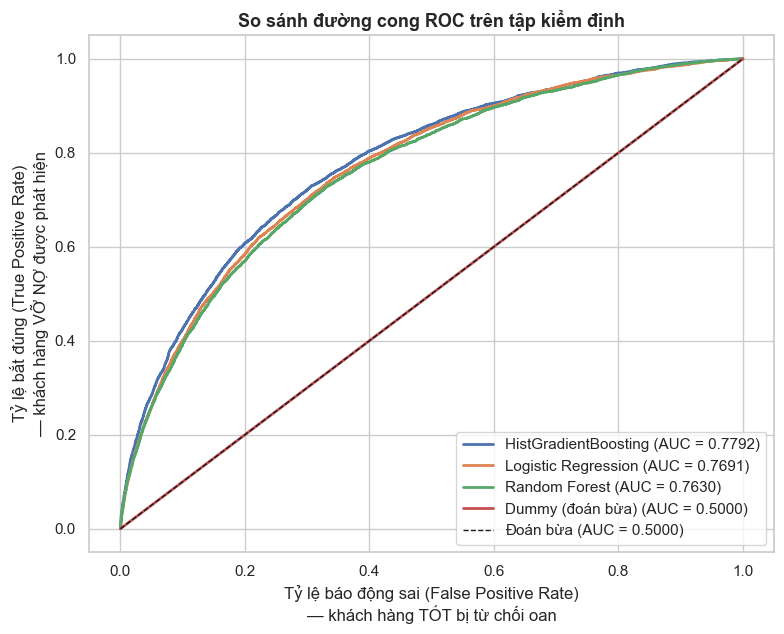

In [6]:
plt.figure(figsize=(8, 6.5))

for name in df_results["Mô hình"]:
    fpr, tpr, _ = roc_curve(y_valid, valid_proba[name])
    auc = df_results.loc[df_results["Mô hình"] == name, "AUC-ROC"].iloc[0]
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Đoán bừa (AUC = 0.5000)")
plt.xlabel("Tỷ lệ báo động sai (False Positive Rate)\n— khách hàng TỐT bị từ chối oan")
plt.ylabel("Tỷ lệ bắt đúng (True Positive Rate)\n— khách hàng VỠ NỢ được phát hiện")
plt.title("So sánh đường cong ROC trên tập kiểm định", fontsize=13, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Nhận xét:** Cả ba mô hình thật đều nằm hẳn phía trên đường chéo đoán bừa. Đường cong của `HistGradientBoosting` **bao trọn** hai mô hình còn lại ở gần như mọi ngưỡng — nghĩa là nó tốt hơn một cách nhất quán chứ không phải chỉ thắng ở một điểm may mắn. Đây là căn cứ để chọn nó làm mô hình chính thức.

Hai trục của biểu đồ chính là **đánh đổi kinh doanh cốt lõi**: kéo lên trục tung (bắt được nhiều khách vỡ nợ hơn) luôn phải trả giá bằng việc trượt sang phải (từ chối oan nhiều khách hàng tốt hơn). Không có điểm nào vừa bắt hết vỡ nợ vừa không làm phiền ai — mục 5.1 sẽ chọn điểm cân bằng cụ thể và quy ra số khách hàng thật.

## 5. Đánh giá chi tiết mô hình tốt nhất

In [7]:
best_name = df_results.loc[0, "Mô hình"]
best_model = fitted[best_name]
best_proba = valid_proba[best_name]
best_auc = float(df_results.loc[0, "AUC-ROC"])

assert best_name != "Dummy (đoán bừa)", "Mô hình thật thua cả đoán bừa -> pipeline đặc trưng có vấn đề nghiêm trọng!"
assert best_auc > 0.7, f"AUC {best_auc:.4f} thấp bất thường so với mốc nền kỳ vọng (~0,75+)"

print(f"Mô hình được chọn: {best_name}")
print(f"AUC-ROC mốc nền  : {best_auc:.4f}")

Mô hình được chọn: HistGradientBoosting
AUC-ROC mốc nền  : 0.7792


### 5.1. Chọn ngưỡng quyết định & ý nghĩa thực tế

Mô hình trả về **xác suất vỡ nợ** (0 → 1), nhưng ngân hàng cần một quyết định **duyệt / từ chối** — phải chốt một **ngưỡng**. Mặc định 0,5 là lựa chọn tồi ở đây: với dữ liệu lệch 92/8, gần như không khách hàng nào vượt 0,5 nên mô hình sẽ duyệt hết.

Ta chọn ngưỡng bằng **chỉ số Youden J** (`TPR - FPR` lớn nhất) — điểm trên đường cong ROC cách xa đường đoán bừa nhất, tức cân bằng nhất giữa bắt đúng khách vỡ nợ và không làm phiền khách hàng tốt.

In [8]:
fpr, tpr, thresholds = roc_curve(y_valid, best_proba)
youden_j = tpr - fpr
best_threshold = float(thresholds[np.argmax(youden_j)])

print(f"Ngưỡng tối ưu theo Youden J: {best_threshold:.4f}\n")

# So sánh vài ngưỡng để thấy rõ sự đánh đổi.
rows = []
for thr in [0.10, 0.20, 0.30, round(best_threshold, 4), 0.50, 0.70]:
    y_pred_thr = (best_proba >= thr).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_valid, y_pred_thr, average="binary", zero_division=0
    )
    rows.append({
        "Ngưỡng": thr,
        "Bắt được vỡ nợ (Recall)": rec,
        "Báo đúng khi cảnh báo (Precision)": prec,
        "F1": f1,
        "Tỷ lệ hồ sơ bị từ chối": y_pred_thr.mean(),
    })

df_thr = pd.DataFrame(rows).drop_duplicates(subset="Ngưỡng").sort_values("Ngưỡng").reset_index(drop=True)
display(df_thr.style.format({
    "Ngưỡng": "{:.4f}", "Bắt được vỡ nợ (Recall)": "{:.2%}",
    "Báo đúng khi cảnh báo (Precision)": "{:.2%}", "F1": "{:.4f}",
    "Tỷ lệ hồ sơ bị từ chối": "{:.2%}",
}))

Ngưỡng tối ưu theo Youden J: 0.0747



,Ngưỡng,Bắt được vỡ nợ (Recall),Báo đúng khi cảnh báo (Precision),F1,Tỷ lệ hồ sơ bị từ chối
0,0.0747,73.05%,17.23%,0.2789,34.22%
1,0.1000,62.46%,20.28%,0.3062,24.86%
2,0.2000,33.07%,30.99%,0.3200,8.62%
3,0.3000,17.36%,40.74%,0.2435,3.44%
4,0.5000,3.24%,58.76%,0.0615,0.45%
5,0.7000,0.10%,83.33%,0.0020,0.01%


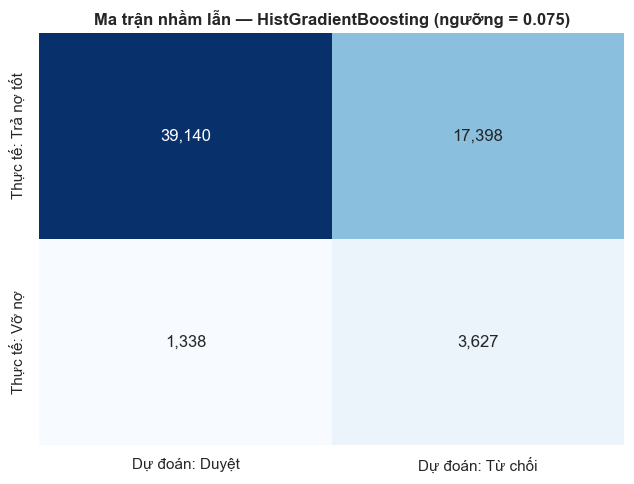

✅ Bắt đúng vỡ nợ (TP)      : 3,627 — tránh được khoản vay xấu
❌ Bỏ sót vỡ nợ (FN)        : 1,338 — ngân hàng MẤT TIỀN
⚠️  Từ chối oan khách tốt (FP): 17,398 — MẤT DOANH THU/khách hàng
✅ Duyệt đúng khách tốt (TN) : 39,140

                precision    recall  f1-score   support

Trả nợ tốt (0)     0.9669    0.6923    0.8069     56538
     Vỡ nợ (1)     0.1725    0.7305    0.2791      4965

      accuracy                         0.6954     61503
     macro avg     0.5697    0.7114    0.5430     61503
  weighted avg     0.9028    0.6954    0.7643     61503



In [9]:
y_pred = (best_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_valid, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Dự đoán: Duyệt", "Dự đoán: Từ chối"],
            yticklabels=["Thực tế: Trả nợ tốt", "Thực tế: Vỡ nợ"])
ax.set_title(f"Ma trận nhầm lẫn — {best_name} (ngưỡng = {best_threshold:.3f})",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"✅ Bắt đúng vỡ nợ (TP)      : {tp:,} — tránh được khoản vay xấu")
print(f"❌ Bỏ sót vỡ nợ (FN)        : {fn:,} — ngân hàng MẤT TIỀN")
print(f"⚠️  Từ chối oan khách tốt (FP): {fp:,} — MẤT DOANH THU/khách hàng")
print(f"✅ Duyệt đúng khách tốt (TN) : {tn:,}\n")
print(classification_report(y_valid, y_pred, target_names=["Trả nợ tốt (0)", "Vỡ nợ (1)"], digits=4))

**Nhận xét — ý nghĩa thực tế (phục vụ Chương 4 whitepaper):**

Bảng ngưỡng cho thấy **sự đánh đổi không thể tránh** của bài toán tín dụng, quy ra số người thật trên 61.503 hồ sơ kiểm định:

| Ngưỡng | Bắt được vỡ nợ | Báo đúng khi cảnh báo | Tỷ lệ hồ sơ bị từ chối |
|---|---|---|---|
| 0,0747 (Youden J) | **73,05%** | 17,23% | **34,22%** |
| 0,20 | 33,07% | 30,99% | 8,62% |
| 0,50 (mặc định) | **3,24%** | 58,76% | 0,45% |

**Ngưỡng mặc định 0,50 gần như vô dụng ở đây:** nó chỉ bắt được **3,24%** khách vỡ nợ — tức bỏ lọt 97% rủi ro — vì với dữ liệu lệch 92/8 rất hiếm hồ sơ nào vượt được xác suất 0,5. Đây là lý do **không được dùng `.predict()` mặc định** của scikit-learn cho bài toán này mà phải tự chốt ngưỡng.

Ở ngưỡng Youden J (0,0747), mô hình bắt được **73% khách hàng sẽ vỡ nợ** (3.627 người), bỏ sót 1.338 người. Cái giá phải trả rất rõ: **17.398 khách hàng tốt bị từ chối oan**, khiến precision chỉ **17,23%** — cứ 6 hồ sơ bị cảnh báo thì chỉ khoảng 1 người thực sự vỡ nợ, và **34% tổng hồ sơ bị từ chối**.

Precision thấp **không có nghĩa mô hình sai** — nó phản ánh đúng bản chất dữ liệu: chỉ 8% khách hàng vỡ nợ, nên bất kỳ bộ lọc nào đủ nhạy cũng sẽ gom theo nhiều khách hàng tốt.

**Cách dùng đúng trong thực tế:** từ chối thẳng 34% hồ sơ là **không chấp nhận được về mặt kinh doanh**. Kết quả này nên dùng để **phân luồng thẩm định** — hồ sơ điểm rủi ro cao chuyển cho chuyên viên xem xét kỹ hoặc yêu cầu thêm tài sản đảm bảo, thay vì loại tự động. Ngưỡng cuối cùng là **quyết định kinh doanh**: nó phụ thuộc ngân hàng coi mất tiền vì một khoản nợ xấu (FN) đắt gấp mấy lần mất một khách hàng tốt (FP). Con số 0,5 mặc định của thư viện không hề mang ý nghĩa kinh doanh nào.

### 5.2. Đặc trưng nào ảnh hưởng mạnh nhất?

Dùng **permutation importance**: xáo trộn ngẫu nhiên giá trị của một cột rồi đo AUC tụt bao nhiêu — tụt càng nhiều thì cột đó càng quan trọng. Cách này đo trên **tập kiểm định** nên phản ánh sức dự báo thật, đáng tin hơn `feature_importances_` (vốn dễ thiên vị các biến nhiều giá trị).

> Chạy trên mẫu 10.000 dòng để tiết kiệm thời gian — với 297 đặc trưng, tính trên toàn tập kiểm định sẽ mất rất lâu mà thứ hạng gần như không đổi.

Tính xong trong 38s trên 10,000 dòng kiểm định.



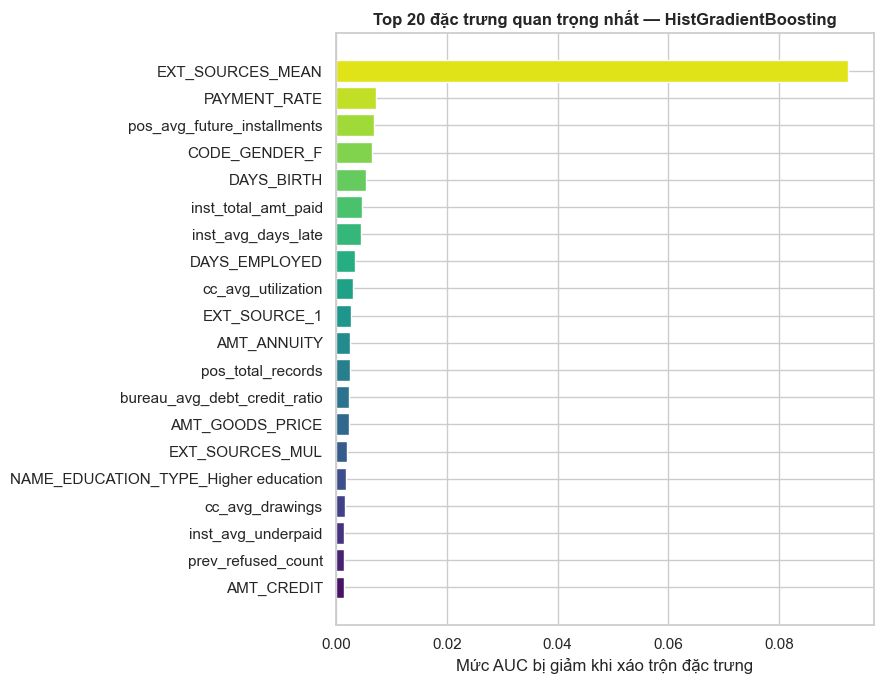

,Đặc trưng,Mức giảm AUC
0,EXT_SOURCES_MEAN,0.09251
1,PAYMENT_RATE,0.00714
2,pos_avg_future_installments,0.00695
3,CODE_GENDER_F,0.00642
4,DAYS_BIRTH,0.00537
5,inst_total_amt_paid,0.00473
6,inst_avg_days_late,0.00457
7,DAYS_EMPLOYED,0.00353
8,cc_avg_utilization,0.00310
9,EXT_SOURCE_1,0.00263


In [10]:
t0 = time.time()
n_sample = min(10_000, len(X_valid))
X_imp = X_valid.iloc[:n_sample]
y_imp = y_valid.iloc[:n_sample]

perm = permutation_importance(
    best_model, X_imp, y_imp, scoring="roc_auc",
    n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1,
)

df_imp = (pd.DataFrame({"Đặc trưng": feature_names, "Mức giảm AUC": perm.importances_mean})
          .sort_values("Mức giảm AUC", ascending=False).reset_index(drop=True))
print(f"Tính xong trong {time.time() - t0:.0f}s trên {n_sample:,} dòng kiểm định.\n")

top = df_imp.head(20).iloc[::-1]
plt.figure(figsize=(9, 7))
plt.barh(top["Đặc trưng"], top["Mức giảm AUC"], color=sns.color_palette("viridis", len(top)))
plt.xlabel("Mức AUC bị giảm khi xáo trộn đặc trưng")
plt.title(f"Top 20 đặc trưng quan trọng nhất — {best_name}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

display(df_imp.head(10).style.format({"Mức giảm AUC": "{:.5f}"}))

**Nhận xét:** Kết quả có một chi tiết **bất ngờ và rất đáng đưa vào báo cáo**:

| Hạng | Đặc trưng | Mức giảm AUC | Nguồn gốc |
|---|---|---|---|
| 1 | `EXT_SOURCES_MEAN` | **0,09251** | **biến phái sinh (NB05)** |
| 2 | `PAYMENT_RATE` | 0,00714 | biến tương tác (NB05) |
| 3 | `pos_avg_future_installments` | 0,00695 | **bảng phụ POS_CASH** |
| 4 | `CODE_GENDER_F` | 0,00642 | cột gốc |
| 5 | `DAYS_BIRTH` | 0,00537 | cột gốc |
| 6 | `inst_total_amt_paid` | 0,00473 | **bảng phụ installments** |
| 7 | `inst_avg_days_late` | 0,00457 | **bảng phụ installments** |

**1. `EXT_SOURCES_MEAN` áp đảo tuyệt đối** — mức giảm AUC gấp **13 lần** biến đứng thứ hai. Đây là biến **do Notebook 05 tự tạo** (trung bình 3 điểm tín dụng từ tổ chức chấm điểm bên ngoài), không phải cột có sẵn. Gần như toàn bộ sức mạnh dự báo của mô hình nằm ở một đặc trưng phái sinh duy nhất.

**2. ⚠️ Cẩn thận khi đọc bảng này — `EXT_SOURCE_1` xếp hạng 10 KHÔNG có nghĩa nó vô dụng.** Permutation importance hoạt động bằng cách xáo trộn từng cột rồi đo AUC tụt bao nhiêu. Khi hai cột **tương quan mạnh** (ở đây `EXT_SOURCE_1/2/3` và trung bình của chính chúng), xáo một cột thì mô hình vẫn đọc được thông tin từ cột kia nên AUC gần như không giảm → điểm quan trọng bị **chia nhỏ và đánh giá thấp một cách giả tạo**. Kết luận đúng là *"nhóm EXT_SOURCE quan trọng bậc nhất"*, **không phải** *"EXT_SOURCE_1 ít quan trọng"*.

**3. Bằng chứng đo được cho Phần B của đề bài:** 3 trong 7 vị trí đầu là đặc trưng "đào" từ **bảng phụ** (`pos_avg_future_installments`, `inst_total_amt_paid`, `inst_avg_days_late`) — lịch sử trả góp và POS. Chúng **vượt qua nhiều cột gốc** của `application_train`. Công sức tổng hợp bảng phụ ở Notebook 05 có giá trị đo được, không phải làm cho có.

**4. Biến tương tác tài chính có tác dụng:** `PAYMENT_RATE` (tỷ lệ khoản trả hàng năm trên tổng khoản vay) đứng hạng 2 — đúng trực giác thẩm định: người vay quá sức so với khả năng trả thì rủi ro cao hơn.

## 6. Lưu mô hình & siêu dữ liệu

Lưu hai file:

1. **`models/model.pkl`** — mô hình tốt nhất (đối tượng scikit-learn thuần), nạp bằng `joblib.load()`.
2. **`models/model_metadata.json`** — **danh sách 297 đặc trưng theo đúng thứ tự lúc train**, ngưỡng quyết định và điểm AUC.

> ⚠️ **Vì sao cần file metadata:** scikit-learn yêu cầu dữ liệu dự đoán có **đúng số cột, đúng thứ tự** như lúc huấn luyện. App Streamlit và Notebook 07 không thể tự đoán thứ tự này — thiếu file metadata, người làm app sẽ phải mở lại notebook mò từng cột, hoặc tệ hơn là **đưa sai thứ tự cột mà không nhận ra** (mô hình vẫn chạy, chỉ trả về kết quả rác). Đây đúng kiểu **lỗi âm thầm** mà nhóm đã dính ở NB03/NB05.

In [11]:
joblib.dump(best_model, MODEL_PATH)

metadata = {
    "model_name": best_name,
    "model_class": type(best_model).__name__,
    "auc_roc_valid": round(best_auc, 4),
    "decision_threshold": round(best_threshold, 4),
    "n_features": len(feature_names),
    "feature_names": feature_names,
    "trained_on_rows": int(len(X_train)),
    "random_state": RANDOM_STATE,
    "debug_mode": DEBUG,
    "scaler_path": "models/scaler.pkl",
    "trained_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "note": "Moc nen (baseline) tu T11 - chua toi uu sieu tham so (viec cua T24).",
}
with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

size_mb = MODEL_PATH.stat().st_size / 1024**2
print(f"✅ Đã lưu {MODEL_PATH.name} ({size_mb:.1f} MB)")
print(f"✅ Đã lưu {METADATA_PATH.name} ({len(feature_names)} đặc trưng)")

✅ Đã lưu model.pkl (1.0 MB)


✅ Đã lưu model_metadata.json (297 đặc trưng)


In [12]:
# --- Kiểm chứng: nạp lại từ đĩa và dự đoán, phải ra ĐÚNG kết quả đã đo ---------
# Không tin "đã lưu xong là xong". Bài học NB05: chữ nói một đằng, file một nẻo.
reloaded = joblib.load(MODEL_PATH)
with open(METADATA_PATH, encoding="utf-8") as f:
    meta_check = json.load(f)

proba_reloaded = reloaded.predict_proba(X_valid[meta_check["feature_names"]])[:, 1]
auc_reloaded = roc_auc_score(y_valid, proba_reloaded)

assert MODEL_PATH.stat().st_size > 0, "model.pkl rỗng 0 byte!"
assert np.allclose(proba_reloaded, best_proba), "Mô hình nạp lại cho kết quả KHÁC -> file hỏng"
assert abs(auc_reloaded - best_auc) < 1e-9, "AUC sau khi nạp lại không khớp"
assert meta_check["feature_names"] == feature_names, "Thứ tự đặc trưng trong metadata sai"

print(f"✅ Nạp lại model.pkl từ đĩa: AUC = {auc_reloaded:.4f} — khớp chính xác với kết quả đã đo.")
print(f"✅ File sẵn sàng cho app Streamlit và Notebook 07.")

✅ Nạp lại model.pkl từ đĩa: AUC = 0.7792 — khớp chính xác với kết quả đã đo.
✅ File sẵn sàng cho app Streamlit và Notebook 07.


**Nhận xét:** `models/model.pkl` (trước đây là **file rỗng 0 byte**) nay đã là mô hình thật, và được **kiểm chứng bằng cách nạp lại từ đĩa rồi dự đoán lại** — AUC khớp tuyệt đối với con số đo lúc train. Hai task đang bị chặn (app Streamlit, Notebook 07) có thể bắt đầu ngay.

Cách dùng ở phía app:

```python
import joblib, json
model = joblib.load("models/model.pkl")
meta  = json.load(open("models/model_metadata.json", encoding="utf-8"))
# X_new phải có ĐÚNG các cột trong meta["feature_names"], ĐÚNG thứ tự đó,
# và phải đi qua models/scaler.pkl của NB05 trước.
proba = model.predict_proba(X_new[meta["feature_names"]])[:, 1]
ket_qua = "TỪ CHỐI" if proba[0] >= meta["decision_threshold"] else "DUYỆT"
```

## 7. Tổng kết

**Kết quả đạt được**

1. **Đã có mô hình chính thức:** `HistGradientBoosting` thắng cả Logistic Regression (0,7691) lẫn Random Forest (0,7630), đạt **AUC-ROC = 0,7792** trên 61.503 dòng kiểm định chưa từng thấy — vượt xa mốc đoán bừa 0,5000. `models/model.pkl` từ file rỗng 0 byte nay đã là mô hình thật (1,0 MB), có kiểm chứng nạp lại từ đĩa.
2. **Đã so sánh 4 mô hình** — thỏa yêu cầu *"có so sánh HOẶC tối ưu mô hình"* (Phần A mục 8).
3. **Đã chứng minh bằng số vì sao không dùng accuracy:** `DummyClassifier` đạt **91,93%** accuracy, còn mô hình tốt nhất **92,01%** — chênh nhau **0,08 điểm phần trăm**. Nhưng AUC là **0,50 so với 0,78**. Đây là **luận điểm nên đưa vào Chương 4 whitepaper**.
4. **Đã xác nhận giá trị của Notebook 05:** đặc trưng phái sinh `EXT_SOURCES_MEAN` quan trọng gấp **13 lần** biến kế tiếp, và 3 trong 7 đặc trưng mạnh nhất được "đào" từ bảng phụ (installments, POS_CASH) — bằng chứng đo được cho **Phần B đề bài**.
5. **Đã diễn giải ý nghĩa thực tế:** ngưỡng mặc định 0,5 chỉ bắt được 3,24% khách vỡ nợ nên **không dùng được**; ở ngưỡng Youden J (0,0747) bắt được 73% nhưng từ chối oan 17.398 khách tốt → khuyến nghị dùng mô hình để **phân luồng thẩm định** thay vì từ chối tự động.

**Hạn chế cần nói rõ (tính trung thực — tiêu chí Y4)**

- Đây là **mốc nền, chưa tinh chỉnh siêu tham số**. Tham số hiện tại chọn theo kinh nghiệm để chạy nhanh, chưa qua tìm kiếm. **AUC 0,7792 là mốc để T24 so sánh.**
- Đánh giá bằng **một lần chia holdout**, chưa cross-validation — con số AUC có thể xê dịch nhẹ tùy cách chia.
- Chưa thử **SMOTE** hay các kỹ thuật lấy mẫu lại; hiện chỉ dùng `class_weight="balanced"`.
- **Khoảng cách giữa 3 mô hình rất hẹp (~0,016)** → nhiều khả năng đổi thuật toán sẽ không cải thiện nhiều bằng việc thêm đặc trưng tốt. Gợi ý cho T24.
- **Rủi ro phụ thuộc `EXT_SOURCE_*`:** mô hình dựa gần như hoàn toàn vào điểm tín dụng mua từ bên thứ ba. Nếu nguồn này ngừng cung cấp hoặc thiếu dữ liệu với khách hàng mới, mô hình sẽ **yếu đi nghiêm trọng**. Đây là hạn chế thực tế cần nêu trong báo cáo.

**Bước tiếp theo**

- **Notebook 07 — Prediction Demo:** nạp `model.pkl` + `scaler.pkl`, demo dự đoán trên hồ sơ mới.
- **App Streamlit:** dùng `model_metadata.json` để dựng form nhập liệu đúng thứ tự 297 cột.
- **Task T24 — tối ưu mô hình:** tinh chỉnh siêu tham số, thử cross-validation và SMOTE, lấy **AUC 0,7792** làm mốc nền để so sánh.